# 🚀 Mission 11: 기계 번역 (Machine Translation)

## 0. 미션 설명

**[개요]**
이번 미션은 **기계 번역(Machine Translation) 실습**으로, 한국어 문장을 영어로 번역하는 모델을 구축하는 프로젝트입니다. 총 3가지 모델(**Seq2Seq 기본**, **Attention 적용**, **성능 비교**)을 구현하고 학습시키며, 각 모델의 성능을 분석하는 것이 핵심 목표입니다.

### 1. 사용 데이터셋
* **데이터 형식:** JSON 파일 (Key: `"ko"`: 한국어, `"mt"`: 영어)
* **다운로드:** 미션 11 데이터 셋 활용
* **파일 경로 예시:**
    * 훈련 데이터: `.../일상생활및구어체_한영_train_set.json`
    * 검증 데이터: `.../일상생활및구어체_한영_valid_set.json`
    *(※ 파일 경로는 본인의 환경에 맞게 수정 필요)*

### 2. 가이드라인

#### 1) 데이터 전처리
* **토크나이저(Tokenizer):** 한국어 및 영어 문장에 적합한 토크나이저를 선택하여 토큰화 진행
* **길이 설정:** 문장 길이를 분석하여 최대 길이(`MAX_LENGTH`) 설정
* **특수 토큰:** 필요시 `SOS`(Start), `EOS`(End), `PAD`(Padding), `UNK`(Unknown) 정의

#### 2) 어휘 사전 구축
* **사전 구성:** 한국어/영어 각각의 어휘 사전 생성
* **빈도 고려:** 단어 등장 빈도를 고려하여 임베딩 및 모델 구성에 활용

#### 3) 텐서 변환 및 데이터 로더
* **인덱싱 & 패딩:** 문장을 인덱스 시퀀스로 변환 후 `PAD` 토큰으로 고정 길이 패딩
* **DataLoader:** `TensorDataset`과 `DataLoader`를 활용하여 배치(Batch) 단위 처리 구현

#### 4) 모델 구현 및 학습
* **Seq2Seq 모델 (Baseline):**
    * GRU 기반 Encoder-Decoder 구조
    * **Teacher Forcing** 기법 적용
* **Attention 모델:**
    * Bahdanau 또는 Luong Attention을 적용한 디코더 구현
    * 기본 모델 대비 번역 성능 향상 검증

#### 5) 모델 학습 및 평가
* **학습 진행:** 각 모델별 학습 수행
* **평가 함수:** 무작위 문장 쌍에 대한 번역 결과 출력 및 정성적 확인
* **결과 정제:** 출력 문장에서 특수 토큰 등을 제거하여 최종 문장 도출

### 3. 추가 실험 (선택 사항)
* **전처리 개선:** 불용어(Stopwords) 제거, 텍스트 정규화 등
* **모델 구조 변경:** 레이어 수, 은닉 상태(Hidden State) 크기 조절, Attention 기법 수정
* **하이퍼파라미터 튜닝:** 학습률(Learning Rate), 배치 크기(Batch Size) 등 최적화
* **정량적 평가:** BLEU Score 등 평가지표 도입

### 4. 제출 안내
* **파일명:** `11_{팀명}_{성함}.ipynb`
* **필수 포함 내용:**
    1.  **모델 구현 및 학습 결과:** (로드 → 전처리 → 임베딩 → 모델링 → 평가) 전 과정
    2.  **Markdown 설명:** 각 코드 셀의 의도, 알고리즘, 함수 설명 상세 기록
    3.  **성능 평가:** 테스트 데이터에 대한 번역 결과 및 정성적/정량적 분석

### 5. 참고 사항
* **Baseline Code:** 초기 모델 구성을 돕기 위한 기본 코드 제공 (링크 참고)
* **주의:** Baseline은 참고용이며, 이를 그대로 제출하기보다 본인의 아이디어를 더해 발전시키는 것이 중요합니다.

## 1. 기본 환경세팅

### (1) 환경 및 데이터 파일 점검

In [10]:
import torch
import os

print("=== 1. 주방 도구(Mac GPU) 점검 ===")

# Mac의 MPS(Metal Performance Shaders) 가속이 가능한지 확인
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"✅ MPS를 사용합니다! 🚀")
else:
    device = torch.device("cpu")
    print("⚠️ MPS를 사용할 수 없어 휴대용 CPU를 사용합니다.")

print(f"   -> 결정된 장치: {device}")

print("\n=== 2. 식재료(데이터 파일) 점검 ===")
# 파일 이름 확인 (대소문자나 띄어쓰기가 정확해야 합니다)
train_filename = "일상생활및구어체_한영_train_set.json"
valid_filename = "일상생활및구어체_한영_valid_set.json"

# 현재 폴더에 파일이 있는지 체크
if os.path.exists(train_filename) and os.path.exists(valid_filename):
    print(f"✅ 재료가 준비되었습니다!")
    print(f"   - 훈련용: {train_filename}")
    print(f"   - 검증용: {valid_filename}")
else:
    print("❌ 재료를 찾을 수 없습니다!")
    print(f"   현재 폴더 위치: {os.getcwd()}")
    print("   [해결법] Colab 왼쪽 폴더 아이콘을 누르고, 파일 두 개를 드래그해서 넣어주세요.")
    
    # 현재 폴더 파일 목록 출력
    print(f"   현재 폴더에 있는 파일들: {os.listdir('.')}")

=== 1. 주방 도구(Mac GPU) 점검 ===
✅ MPS를 사용합니다! 🚀
   -> 결정된 장치: mps

=== 2. 식재료(데이터 파일) 점검 ===
✅ 재료가 준비되었습니다!
   - 훈련용: 일상생활및구어체_한영_train_set.json
   - 검증용: 일상생활및구어체_한영_valid_set.json


### (2) 데이터 박스 열어보기 (Load & Inspect)

In [11]:
import json
import random

# 1. 데이터 로드 함수
def load_json_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    # 이 데이터셋은 내부에 'data'라는 키 안에 실제 리스트가 들어있는 구조입니다.
    return data['data']

# 2. 파일 읽어오기
print("📦 데이터를 박스에서 꺼내는 중...")
train_data = load_json_data(train_filename)
valid_data = load_json_data(valid_filename)

print(f"✅ 로드 완료!")
print(f"   - 훈련 데이터(Train): {len(train_data)} 문장")
print(f"   - 검증 데이터(Valid): {len(valid_data)} 문장")

# 3. 랜덤으로 하나 찍어서 맛보기 (제대로 짝이 맞는지 확인)
print("\n🔍 [랜덤 샘플 확인]")
sample = random.choice(train_data)
print(f"🇰🇷 한국어: {sample['ko']}")
print(f"🇺🇸 영  어: {sample['mt']}")

📦 데이터를 박스에서 꺼내는 중...
✅ 로드 완료!
   - 훈련 데이터(Train): 1200000 문장
   - 검증 데이터(Valid): 150000 문장

🔍 [랜덤 샘플 확인]
🇰🇷 한국어: 저쪽은 거래가 안 되는데, 무료로 받을 수 있는 방법이 있나요?
🇺🇸 영  어: There is no transaction over there, is there a way to get it for free?


### (3) EDA

📊 문장 길이를 분석 중입니다... (잠시만 기다려주세요)
✅ 분석 완료!


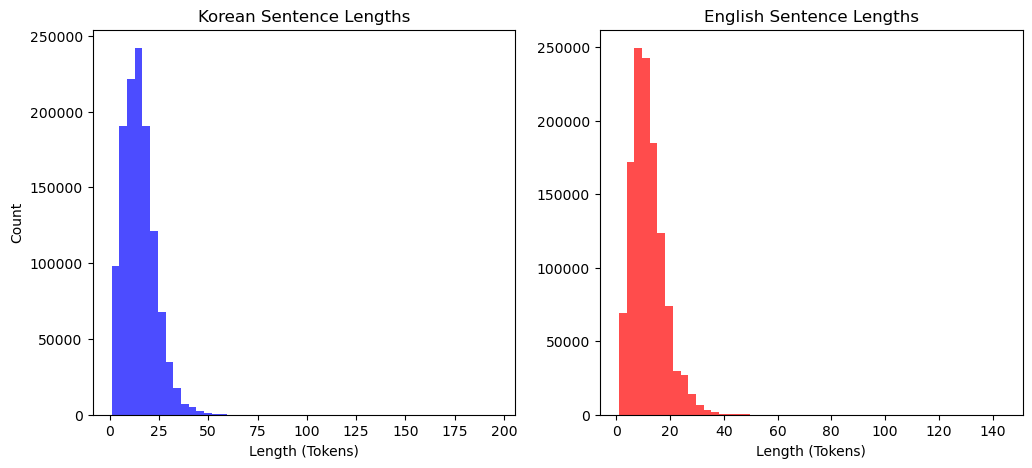


[한국어 길이 통계]
  - 최소 길이: 1
  - 최대 길이: 196
  - 평균 길이: 14.78
  - 95%의 데이터가 29 단어 이하입니다.
  - 99%의 데이터가 38 단어 이하입니다.

[영어 길이 통계]
  - 최소 길이: 1
  - 최대 길이: 144
  - 평균 길이: 11.71
  - 95%의 데이터가 23 단어 이하입니다.
  - 99%의 데이터가 30 단어 이하입니다.


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 길이 측정 (이미 토크나이저가 준비되었으니 그걸 씁니다)
print("📊 문장 길이를 분석 중입니다... (잠시만 기다려주세요)")

# 한국어 문장 길이 (토큰 개수)
ko_lens = [len(kiwi.tokenize(item['ko'])) for item in train_data]

# 영어 문장 길이 (토큰 개수)
en_lens = [len(nltk.word_tokenize(item['mt'])) for item in train_data]

print("✅ 분석 완료!")

# 2. 시각화 (히스토그램)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(ko_lens, bins=50, color='blue', alpha=0.7)
plt.title('Korean Sentence Lengths')
plt.xlabel('Length (Tokens)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(en_lens, bins=50, color='red', alpha=0.7)
plt.title('English Sentence Lengths')
plt.xlabel('Length (Tokens)')

plt.show()

# 3. 통계 수치 확인 (이게 진짜 중요합니다!)
def print_percentile(lens, name):
    print(f"\n[{name} 길이 통계]")
    print(f"  - 최소 길이: {np.min(lens)}")
    print(f"  - 최대 길이: {np.max(lens)}")
    print(f"  - 평균 길이: {np.mean(lens):.2f}")
    print(f"  - 95%의 데이터가 {np.percentile(lens, 95):.0f} 단어 이하입니다.")
    print(f"  - 99%의 데이터가 {np.percentile(lens, 99):.0f} 단어 이하입니다.")

print_percentile(ko_lens, "한국어")
print_percentile(en_lens, "영어")

> 최대 길이(196)**에 맞추면? -> 대부분의 문장은 짧은데, 빈 공간(PAD)만 잔뜩 채우게 되어 메모리와 속도 낭비가 심합니다.
> 99% 기준(38)**에 맞추면? -> 40 정도로만 설정해도 전체 데이터의 99%를 손실 없이 학습할 수 있습니다. (나머지 1%의 엄청 긴 문장은 잘리겠지만, 학습 효율을 위해 허용할 만한 수준입니다.)



## 2. 토큰 및 사전화 작업

In [15]:
from kiwipiepy import Kiwi
import nltk

# 1. 토크나이저 초기화 (새로운 칼: Kiwi)
print("🔪 새로운 토크나이저(Kiwi) 준비 중...")
kiwi = Kiwi()
print("✅ Java 없이 돌아가는 Kiwi 준비 완료!")

# 2. 잘 썰리는지 테스트
test_sent_ko = "나는 학교에 간다"
tokens = [token.form for token in kiwi.tokenize(test_sent_ko)]
print(f"\n[테스트] 원문: {test_sent_ko}")
print(f" -> 토큰화 결과: {tokens}")

# --- 여기서부터는 아까와 같습니다 ---

# 특수 토큰 정의
SOS_token = 0
EOS_token = 1
PAD_token = 2
UNK_token = 3

class Lang:
    def __init__(self, name):
        # 처음 문을 열 때, 미리 4개의 번호표는 예약해 둡니다.
        # 0번: SOS (시작!), 1번: EOS (끝!), 2번: PAD (빈칸), 3번: UNK (모름)
        self.name = name
        self.word2index = {SOS_token: "SOS", EOS_token: "EOS", PAD_token: "PAD", UNK_token: "UNK"}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS", 2: "PAD", 3: "UNK"}
        self.n_words = 4 # "지금 4번까지 찼어요~ 다음은 5번!"

    def addSentence(self, sentence, tokenizer, lang_type):
        # 문장이 들어오면 칼(tokenizer)로 단어별로 쪼갭니다.
        # 그리고 단어 하나하나를 등록 창구(addWord)로 보냅니다.
        ...
        if lang_type == 'ko':
            # Kiwi는 결과가 객체로 나오므로 .form만 뽑아내야 합니다
            tokens = [token.form for token in tokenizer.tokenize(sentence)]
        else:
            tokens = nltk.word_tokenize(sentence)
            
        for word in tokens:
            self.addWord(word)

    def addWord(self, word):
        # 처음 보는 단어면? -> 새 번호를 주고 장부에 적습니다.
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

# 3. 실제 데이터로 사전 구축하기 (다시 실행)
# 위에서 데이터를 이미 load했다고 가정합니다 (train_data)
# 만약 train_data 변수가 날아갔으면 이전 단계(데이터 로드)를 한번 실행해주세요.

input_lang = Lang("ko")
output_lang = Lang("en")

print("\n📖 사전을 만들고 있습니다... (Kiwi는 속도도 빠릅니다!)")

for item in train_data:
    input_lang.addSentence(item['ko'], kiwi, 'ko')
    output_lang.addSentence(item['mt'], nltk, 'en')

print(f"✅ 사전 구축 완료!")
print(f"🇰🇷 한국어 단어 수: {input_lang.n_words}개")
print(f"🇺🇸 영어 단어 수:   {output_lang.n_words}개")

🔪 새로운 토크나이저(Kiwi) 준비 중...
✅ Java 없이 돌아가는 Kiwi 준비 완료!


Quantization is not supported for ArchType::neon. Fall back to non-quantized model.



[테스트] 원문: 나는 학교에 간다
 -> 토큰화 결과: ['나', '는', '학교', '에', '가', 'ᆫ다']

📖 사전을 만들고 있습니다... (Kiwi는 속도도 빠릅니다!)
✅ 사전 구축 완료!
🇰🇷 한국어 단어 수: 56798개
🇺🇸 영어 단어 수:   85907개


### (1) 패딩 ( 모든 문장길이를 맞춰줌)

In [16]:
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

# 🎯 결정된 최대 길이 (99% 커버 + 여유분)
MAX_LENGTH = 40

def tensorFromSentence(lang, sentence, tokenizer, is_korean):
    # 1. 토큰화
    if is_korean:
        tokens = [token.form for token in tokenizer.tokenize(sentence)]
    else:
        tokens = nltk.word_tokenize(sentence)

    # 2. 숫자 변환
    indexes = [SOS_token]
    for word in tokens:
        indexes.append(lang.word2index.get(word, UNK_token))
    indexes.append(EOS_token)

    # 3. 길이 맞추기 (Padding & Truncating)
    # 40보다 길면 자르고, 짧으면 PAD(2) 채우기
    if len(indexes) > MAX_LENGTH:
        indexes = indexes[:MAX_LENGTH]
    else:
        while len(indexes) < MAX_LENGTH:
            indexes.append(PAD_token)

    # 4. 텐서 변환
    return torch.tensor(indexes, dtype=torch.long, device=device)

def get_dataloader(data, batch_size=32):
    print(f"🍱 데이터 {len(data)}개를 도시락(Batch)으로 싸는 중... (MAX_LENGTH={MAX_LENGTH})")
    
    input_tensors = []
    target_tensors = []

    for item in data:
        input_tensor = tensorFromSentence(input_lang, item['ko'], kiwi, True)
        target_tensor = tensorFromSentence(output_lang, item['mt'], nltk, False)
        
        input_tensors.append(input_tensor)
        target_tensors.append(target_tensor)

    # 전체를 하나의 텐서로 합치기
    input_tensors = torch.stack(input_tensors)
    target_tensors = torch.stack(target_tensors)

    # 데이터셋 및 로더 생성
    dataset = TensorDataset(input_tensors, target_tensors)
    sampler = RandomSampler(dataset)
    dataloader = DataLoader(dataset, sampler=sampler, batch_size=batch_size)
    
    return dataloader

# === 실행 ===
# 훈련용 로더 (Batch Size 32)
train_dataloader = get_dataloader(train_data, batch_size=32)

# 검증용 로더 (Batch Size 32)
valid_dataloader = get_dataloader(valid_data, batch_size=32)

print("✅ 데이터 준비 최종 완료!")

🍱 데이터 1200000개를 도시락(Batch)으로 싸는 중... (MAX_LENGTH=40)
🍱 데이터 150000개를 도시락(Batch)으로 싸는 중... (MAX_LENGTH=40)
✅ 데이터 준비 최종 완료!
